<a href="https://colab.research.google.com/github/boshetunmay1/paris-real-estate-analysis/blob/main/kursovaya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ЗАГРУЗКА ДАННЫХ

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

file_path = '/content/drive/MyDrive/ParisHousing.csv'

df = pd.read_csv(file_path)
df = df.iloc[350:451]

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style("whitegrid")

# ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ ДАННЫХ

## Характеристики выборки

In [ ]:
print(f"Размер датасета: {df.shape[0]} строк × {df.shape[1]} столбцов")
display(df.head())
info_df = pd.DataFrame({
    'Тип данных':      df.dtypes,
    'Пропусков': df.isnull().sum(),
    'Пропусков %':   (df.isnull().sum() / len(df) * 100).round(2)
})
display(info_df)
display(df.describe().T.round(2))

Размер датасета: 101 строк × 17 столбцов


,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price
350,19649,11,0,1,83,87255,4,4,1999,1,0,595,6282,795,1,2,1970018.9
351,141,16,0,1,58,42248,5,4,1997,1,0,3411,8985,213,0,4,22670.7
352,22821,64,1,1,14,66304,9,8,1993,1,1,2060,103,491,1,2,2289134.3
353,533,76,1,1,55,94923,6,8,2021,1,1,654,3585,301,0,9,65465.1
354,67020,71,1,1,38,64361,4,7,2015,0,0,3647,997,640,0,1,6711051.5


,Тип данных,Пропусков,Пропусков %
squareMeters,int64,0,0.0
numberOfRooms,int64,0,0.0
hasYard,int64,0,0.0
hasPool,int64,0,0.0
floors,int64,0,0.0
cityCode,int64,0,0.0
cityPartRange,int64,0,0.0
numPrevOwners,int64,0,0.0
made,int64,0,0.0
isNewBuilt,int64,0,0.0


,count,mean,std,min,25%,50%,75%,max
squareMeters,101.0,44216.89,29579.24,141.0,18926.0,38700.0,70763.0,99767.0
numberOfRooms,101.0,49.75,29.52,1.0,25.0,51.0,71.0,100.0
hasYard,101.0,0.52,0.50,0.0,0.0,1.0,1.0,1.0
hasPool,101.0,0.53,0.50,0.0,0.0,1.0,1.0,1.0
floors,101.0,53.58,29.58,1.0,32.0,54.0,80.0,99.0
cityCode,101.0,52864.53,29261.99,3.0,27552.0,50519.0,81044.0,99953.0
cityPartRange,101.0,5.98,2.91,1.0,4.0,7.0,8.0,10.0
numPrevOwners,101.0,6.22,2.43,1.0,4.0,7.0,8.0,10.0
made,101.0,2004.80,9.64,1990.0,1996.0,2004.0,2013.0,2021.0
isNewBuilt,101.0,0.49,0.50,0.0,0.0,0.0,1.0,1.0


## Предварительаня обработка данных

In [ ]:
print("Пропуски по каждой колонке:")
missing = df.isnull().sum().rename('Пропусков').to_frame()
missing['%'] = (missing['Пропусков'] / len(df) * 100).round(2)
display(missing)
rows_before = len(df)
df = df.dropna()
rows_after = len(df)
print(f"\nДо удаления строк с пропусками: {rows_before}")
print(f"После удаления: {rows_after}")
print(f"Удалено строк: {rows_before - rows_after}")

Пропуски по каждой колонке:


,Пропусков,%
squareMeters,0,0.0
numberOfRooms,0,0.0
hasYard,0,0.0
hasPool,0,0.0
floors,0,0.0
cityCode,0,0.0
cityPartRange,0,0.0
numPrevOwners,0,0.0
made,0,0.0
isNewBuilt,0,0.0



До удаления строк с пропусками: 101
После удаления: 101
Удалено строк: 0


## Выявление выбросов

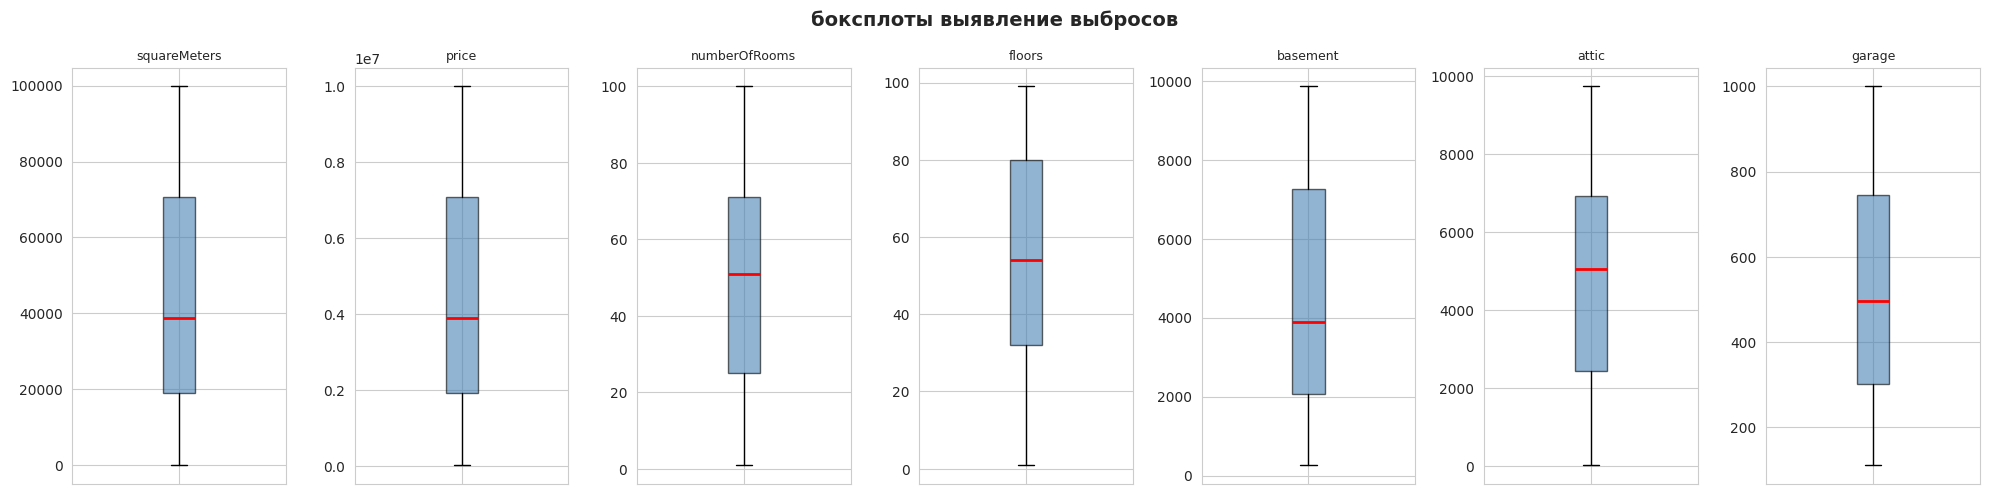

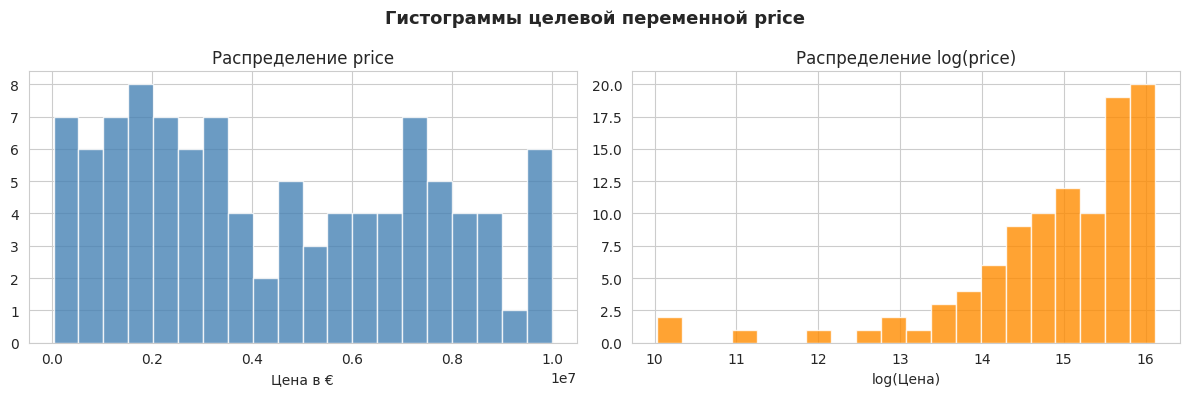

Количество выбросов по IQR
  squareMeters        : 0 выбросов
  price               : 0 выбросов
  numberOfRooms       : 0 выбросов
  floors              : 0 выбросов
  basement            : 0 выбросов
  attic               : 0 выбросов
  garage              : 0 выбросов


In [ ]:
key_cols = ['squareMeters', 'price', 'numberOfRooms',
            'floors', 'basement', 'attic', 'garage']

#боксплоты
fig, axes = plt.subplots(1, len(key_cols), figsize=(20, 5))
fig.suptitle('боксплоты выявление выбросов',
             fontsize=14, fontweight='bold')

for ax, col in zip(axes, key_cols):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontsize=9)
    ax.tick_params(axis='x', bottom=False, labelbottom=False)

plt.tight_layout()
plt.show()

#гистограммы для price
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df['price'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
plt.title('Распределение price')
plt.xlabel('Цена в €')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df['price']), bins=20, color='darkorange',
         edgecolor='white', alpha=0.8)
plt.title('Распределение log(price)')
plt.xlabel('log(Цена)')

plt.suptitle('Гистограммы целевой переменной price', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.show()

#подсчёт выбросов по IQR
print("Количество выбросов по IQR")
for col in key_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  {col:<20}: {n_out} выбросов")

## Стандартизация данных


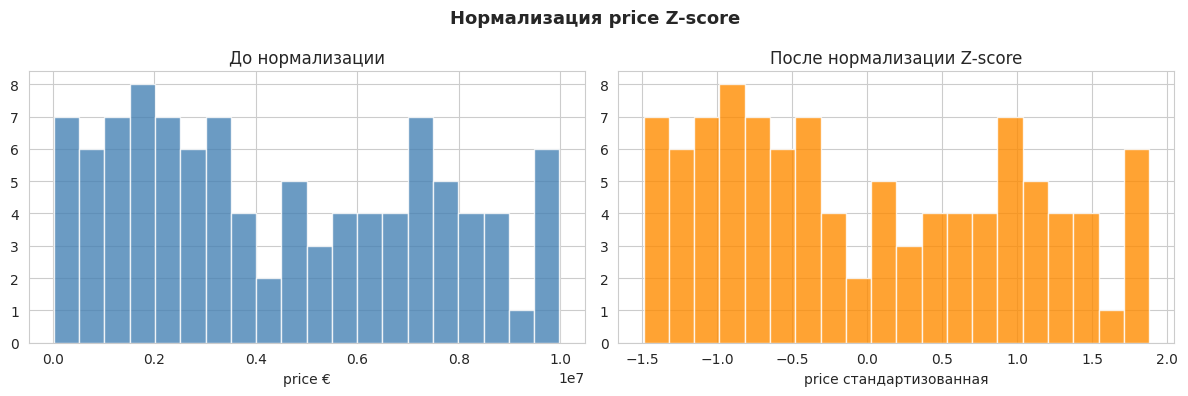

Статистика price_scaled после стандартизации:
count    101.0000
mean      -0.0000
std        1.0000
min       -1.4896
25%       -0.8521
50%       -0.1854
75%        0.8971
max        1.8788
Name: price_scaled, dtype: float64


In [ ]:
cols_to_scale = ['squareMeters', 'price', 'numberOfRooms',
                 'basement', 'attic', 'garage', 'floors']

df_normalized = df.copy()

for col in cols_to_scale:
    mean = df[col].mean()
    std  = df[col].std()
    df_normalized[col + '_scaled'] = (df[col] - mean) / std

#сравнение до/после для price
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Нормализация price Z-score',
             fontsize=13, fontweight='bold')

axes[0].hist(df['price'], bins=20, color='steelblue',
             edgecolor='white', alpha=0.8)
axes[0].set_title('До нормализации')
axes[0].set_xlabel('price €')

axes[1].hist(df_normalized['price_scaled'], bins=20,
             color='darkorange', edgecolor='white', alpha=0.8)
axes[1].set_title('После нормализации Z-score')
axes[1].set_xlabel('price стандартизованная')

plt.tight_layout()
plt.show()

print("Статистика price_scaled после стандартизации:")
print(df_normalized['price_scaled'].describe().round(4))

# ОСНОВНОЙ АНАЛИЗ ДАННЫХ

## Выборки и их характеристики: вычисление основных статистических показателей

### Среднее, медиана, мода, дисперсия

In [ ]:
quant_cols = ['squareMeters', 'price', 'numberOfRooms',
              'floors', 'basement', 'attic', 'garage',
              'numPrevOwners']

stats_df = pd.DataFrame({
    'Среднее':              df[quant_cols].mean(),
    'Медиана':              df[quant_cols].median(),
    'Мода':                 df[quant_cols].mode().iloc[0],
    'Дисперсия':            df[quant_cols].var(),
    'Стандартное отклонение':      df[quant_cols].std(),
}).round(2)

print("Основные статистические показатели")
display(stats_df)

#ковариация и корреляция price
cov_with_price = df[quant_cols].cov()['price'].drop('price').round(2)
corr_with_price = df[quant_cols].corr()['price'].drop('price').round(4)

summary = pd.DataFrame({
    'Ковариация с price':    cov_with_price,
    'Корреляция с price':    corr_with_price
})
print("\nКовариация и корреляция с price")
display(summary)

Основные статистические показатели


,Среднее,Медиана,Мода,Дисперсия,Стандартное отклонение
squareMeters,44216.89,38700.0,141.0,8.749316e+08,29579.24
price,4428739.44,3880396.6,22670.7,8.748962e+12,2957864.41
numberOfRooms,49.75,51.0,98.0,8.712300e+02,29.52
floors,53.58,54.0,38.0,8.751100e+02,29.58
basement,4618.27,3879.0,2060.0,8.821083e+06,2970.03
attic,4934.95,5066.0,42.0,7.599074e+06,2756.64
garage,535.51,496.0,372.0,6.690581e+04,258.66
numPrevOwners,6.22,7.0,7.0,5.910000e+00,2.43



Ковариация и корреляция с price


,Ковариация с price,Корреляция с price
squareMeters,8.749132e+10,1.0000
numberOfRooms,-1.408472e+07,-0.1613
floors,-9.452515e+06,-0.1080
basement,1.488018e+09,0.1694
attic,-8.903226e+08,-0.1092
garage,-4.030050e+07,-0.0527
numPrevOwners,-9.523620e+05,-0.1324


### Гистограммы

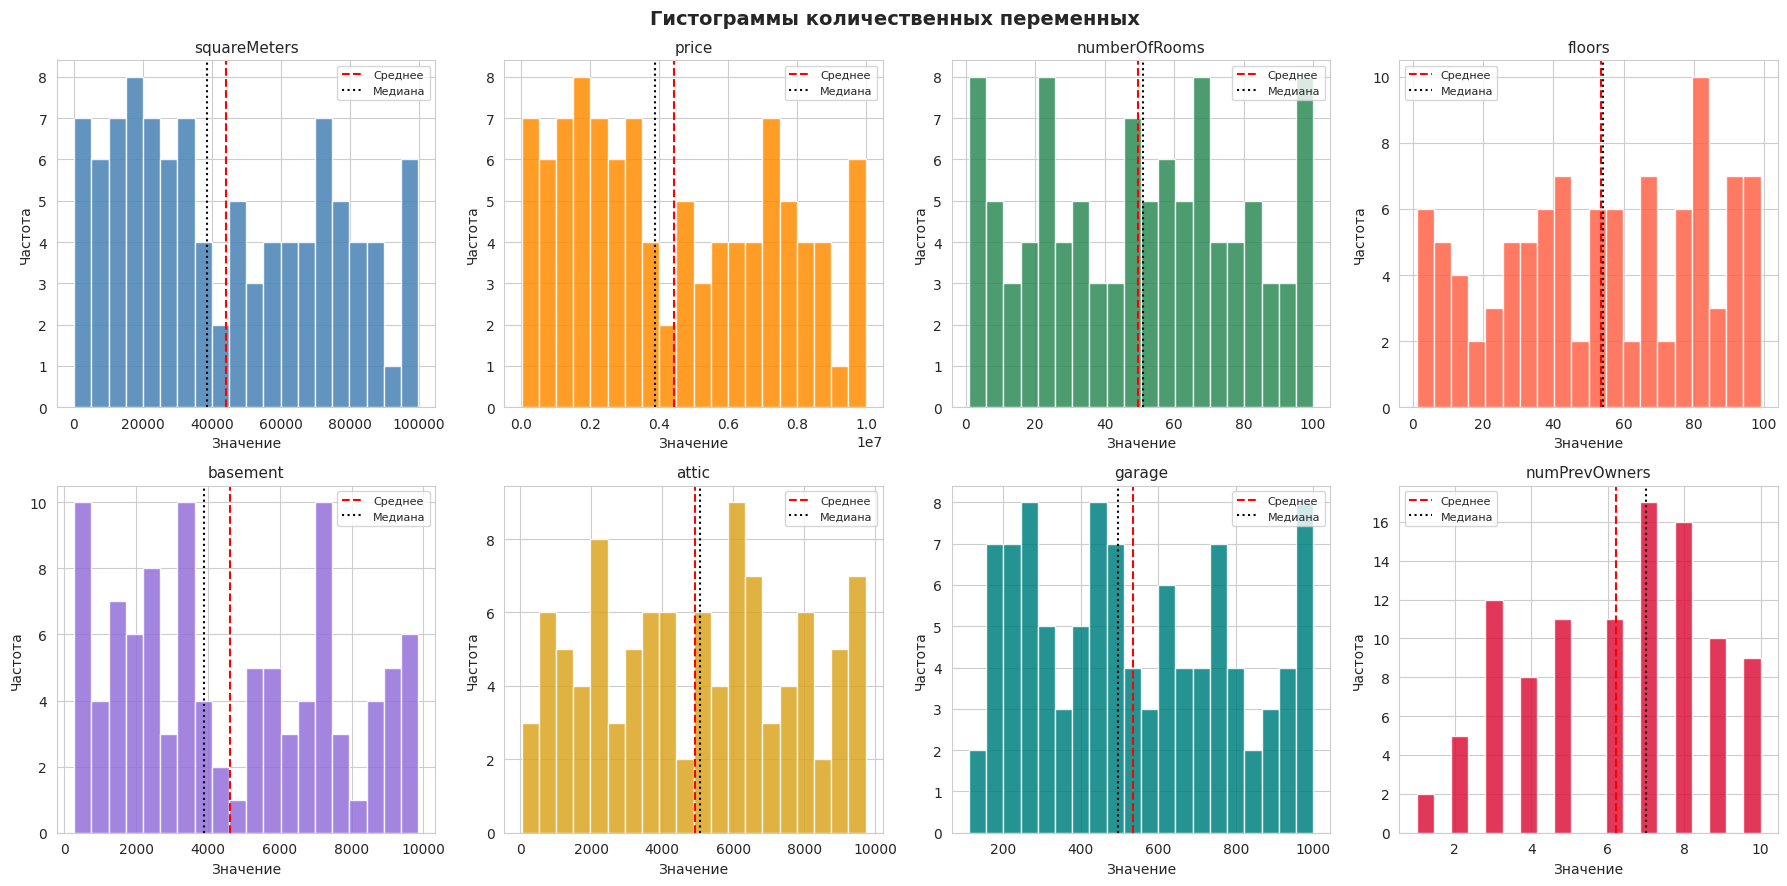

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Гистограммы количественных переменных',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

colors = ['steelblue', 'darkorange', 'seagreen', 'tomato',
          'mediumpurple', 'goldenrod', 'teal', 'crimson']

for i, col in enumerate(quant_cols):
    axes[i].hist(df[col], bins=20, color=colors[i],
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота')
    #линии среднего и медианы
    axes[i].axvline(df[col].mean(),   color='red',   linestyle='--',
                    linewidth=1.5, label='Среднее')
    axes[i].axvline(df[col].median(), color='black', linestyle=':',
                    linewidth=1.5, label='Медиана')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Диаграммы рассеяния

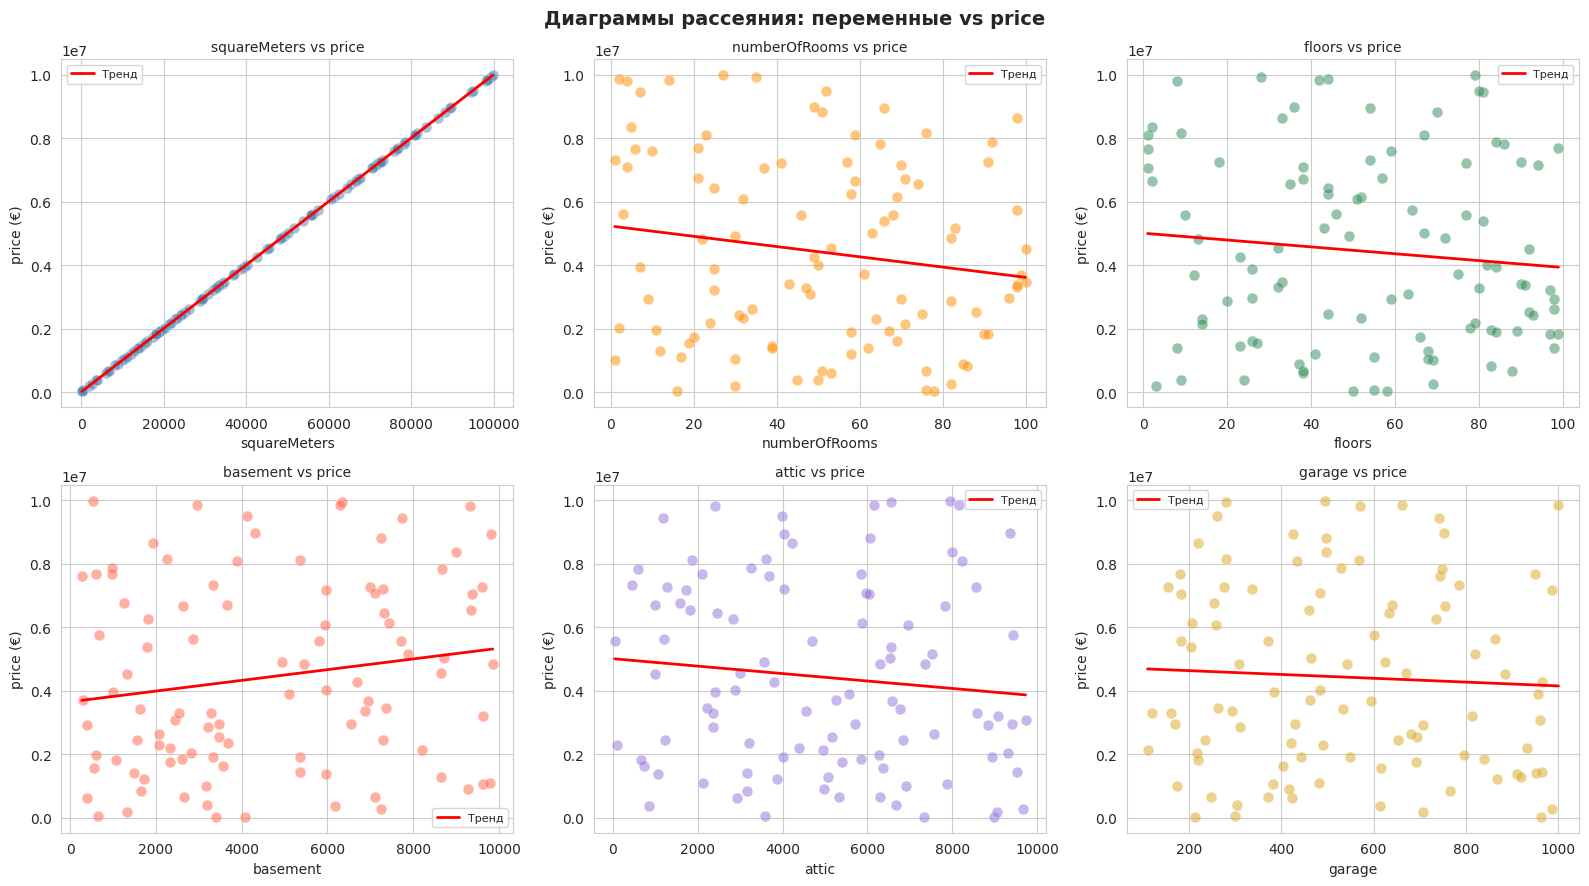

In [ ]:
scatter_vars = ['squareMeters', 'numberOfRooms', 'floors',
                'basement', 'attic', 'garage']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Диаграммы рассеяния: переменные vs price',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(scatter_vars):
    axes[i].scatter(df[col], df['price'],
                    alpha=0.5, color=colors[i], edgecolors='white',
                    linewidths=0.4, s=60)
    #линия тренда
    m, b = np.polyfit(df[col], df['price'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color='red',
                 linewidth=2, label='Тренд')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('price (€)')
    axes[i].set_title(f'{col} vs price', fontsize=10)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Статистические метрики

### Корреляционный анализ

Корреляция Пирсона с переменной price


,r,p-value,Значимость
squareMeters,1.0,0.0,значима
numberOfRooms,-0.1613,0.107,не значима
floors,-0.108,0.2822,не значима
basement,0.1694,0.0904,не значима
attic,-0.1092,0.2771,не значима
garage,-0.0527,0.6009,не значима
numPrevOwners,-0.1324,0.1868,не значима



Корреляция Спирмена с переменной price


,rho,p-value,Значимость
squareMeters,1.0,0.0,значима
numberOfRooms,-0.1341,0.1813,не значима
floors,-0.0887,0.3779,не значима
basement,0.1553,0.1209,не значима
attic,-0.1051,0.2956,не значима
garage,-0.0419,0.6771,не значима
numPrevOwners,-0.1527,0.1273,не значима


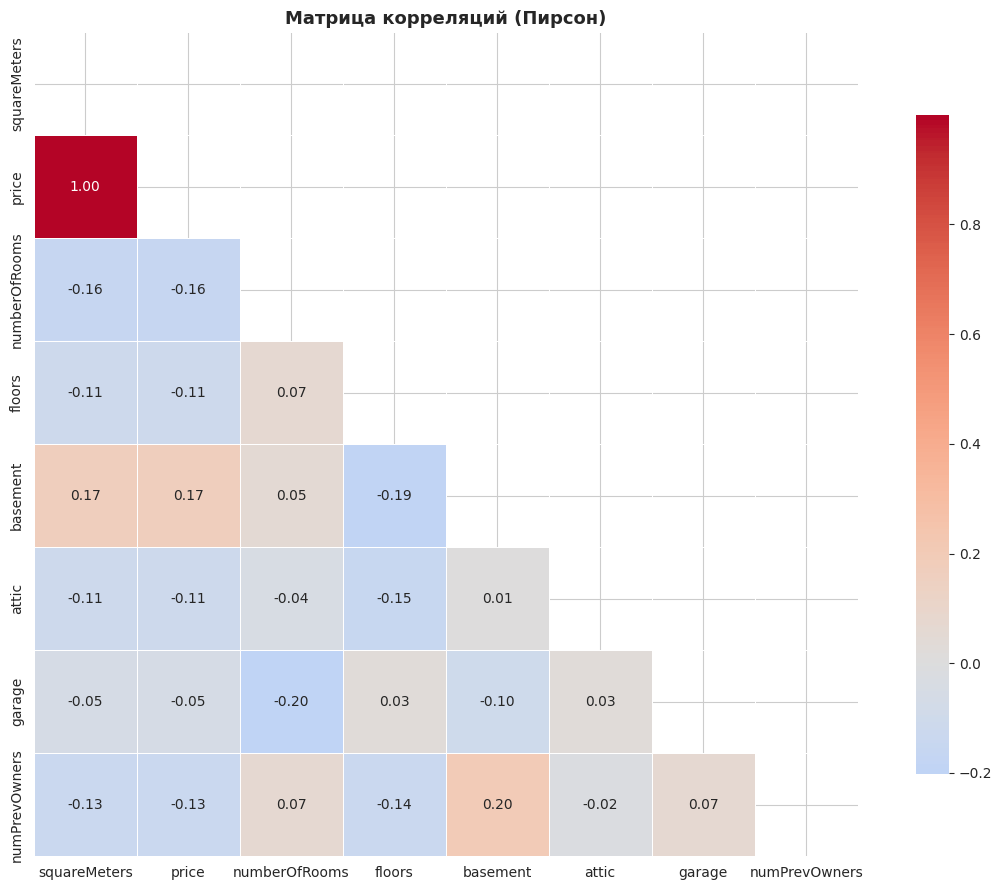

In [ ]:
from scipy.stats import pearsonr, spearmanr

print("Корреляция Пирсона с переменной price")
pearson_results = {}
for col in quant_cols:
    if col == 'price':
        continue
    r, p = pearsonr(df[col], df['price'])
    pearson_results[col] = {'r': round(r, 4), 'p-value': round(p, 4),
                             'Значимость': 'значима' if p < 0.05 else 'не значима'}

display(pd.DataFrame(pearson_results).T)

print("\nКорреляция Спирмена с переменной price")
spearman_results = {}
for col in quant_cols:
    if col == 'price':
        continue
    r, p = spearmanr(df[col], df['price'])
    spearman_results[col] = {'rho': round(r, 4), 'p-value': round(p, 4),
                              'Значимость': 'значима' if p < 0.05 else 'не значима'}

display(pd.DataFrame(spearman_results).T)

#тепловая карта корреляций
plt.figure(figsize=(12, 9))
corr_matrix = df[quant_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Матрица корреляций (Пирсон)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Т-тесты

Независимый t-тест: сравнение средней цены по группам


,Среднее (=0),Среднее (=1),n (=0),n (=1),t-статистика,p-value,Вывод
hasPool,4347003.0,4499880.0,47,54,-0.2589,0.7962,H0 не отвергается
hasYard,4309146.0,4537051.0,48,53,-0.387,0.6996,H0 не отвергается
isNewBuilt,4858862.0,3972283.0,52,49,1.5151,0.1329,H0 не отвергается
hasStormProtector,4561244.0,4263845.0,56,45,0.4987,0.6192,H0 не отвергается
hasStorageRoom,3758685.0,5112195.0,51,50,-2.3536,0.0206,H0 отвергается


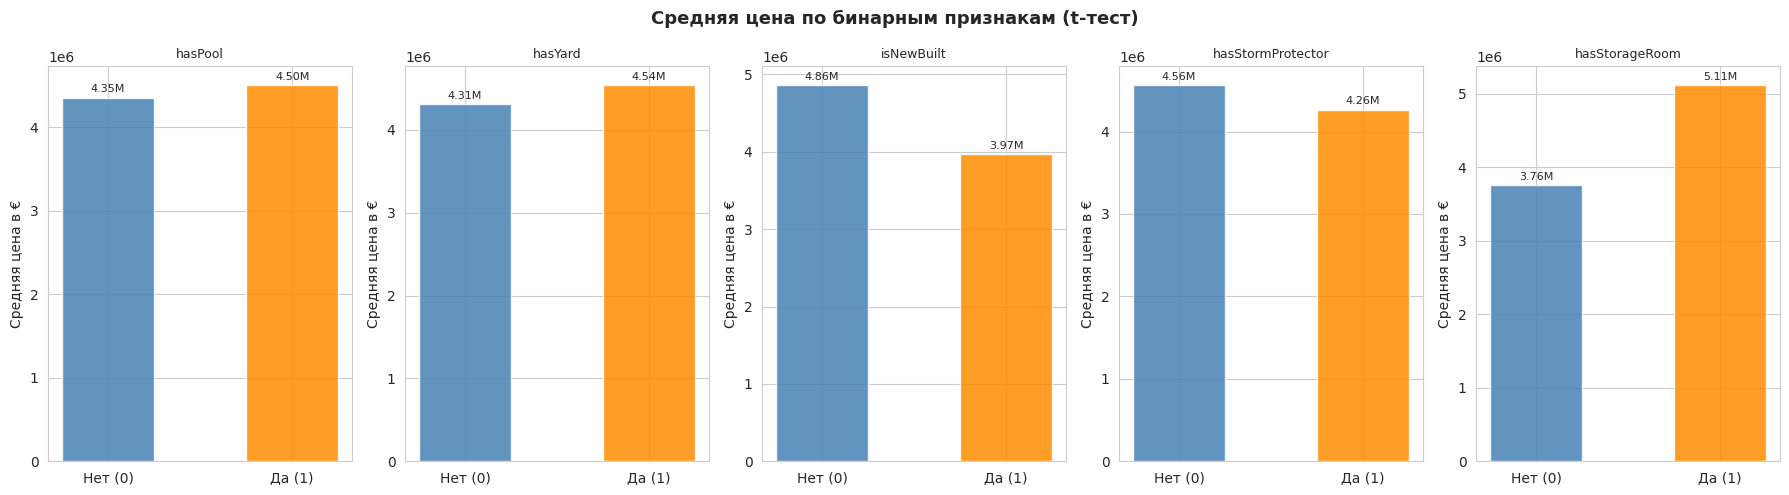

In [ ]:
from scipy.stats import ttest_ind, f_oneway, levene

print("=" * 60)
print("Независимый t-тест: сравнение средней цены по группам")
print("=" * 60)

binary_vars = ['hasPool', 'hasYard', 'isNewBuilt',
               'hasStormProtector', 'hasStorageRoom']

ttest_results = {}
for var in binary_vars:
    group0 = df[df[var] == 0]['price']
    group1 = df[df[var] == 1]['price']
    t_stat, p_val = ttest_ind(group0, group1, equal_var=False)
    ttest_results[var] = {
        'Среднее (=0)': round(group0.mean(), 0),
        'Среднее (=1)': round(group1.mean(), 0),
        'n (=0)':       len(group0),
        'n (=1)':       len(group1),
        't-статистика': round(t_stat, 4),
        'p-value':      round(p_val, 4),
        'Вывод':        'H0 отвергается' if p_val < 0.05 else 'H0 не отвергается'
    }

display(pd.DataFrame(ttest_results).T)

#визуализация t-теста
fig, axes = plt.subplots(1, len(binary_vars), figsize=(18, 5))
fig.suptitle('Средняя цена по бинарным признакам (t-тест)',
             fontsize=13, fontweight='bold')

for ax, var in zip(axes, binary_vars):
    means = df.groupby(var)['price'].mean()
    bars = ax.bar(['Нет (0)', 'Да (1)'], means.values,
                  color=['steelblue', 'darkorange'], edgecolor='white',
                  alpha=0.85, width=0.5)
    ax.set_title(var, fontsize=9)
    ax.set_ylabel('Средняя цена в €')
    #подписи значений
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f'{val/1e6:.2f}M', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

###  F-тест и ANOVA

F-тест Левена: равенство дисперсий price по hasStorageRoom
Статистика Левена: 0.2842
p-value:           0.5951
Вывод: Дисперсии статистически равны

 ANOVA: средняя цена по квартилям numberOfRooms
F-статистика: 1.3776
p-value:      0.2542
Вывод: Значимых различий не выявлено

Средняя цена по группам numberOfRooms:


,mean,count
rooms_group,,
Q1 (низкий),5117868.0,28
Q2,4145689.0,24
Q3,4780796.0,24
Q4 (высокий),3590670.0,25


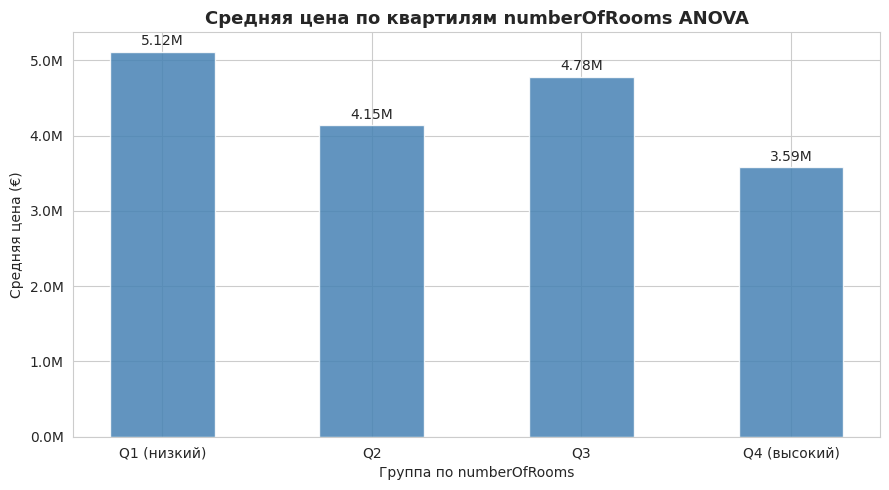

In [ ]:
from scipy.stats import levene, f_oneway

#F-тест Левена - равенство дисперсий price по hasStorageRoom
#берем значимый признак из t-теста
print("F-тест Левена: равенство дисперсий price по hasStorageRoom")
group0 = df[df['hasStorageRoom'] == 0]['price']
group1 = df[df['hasStorageRoom'] == 1]['price']

lev_stat, lev_p = levene(group0, group1)
print(f"Статистика Левена: {lev_stat:.4f}")
print(f"p-value:           {lev_p:.4f}")
print(f"Вывод: {'Дисперсии значимо различаются' if lev_p < 0.05 else 'Дисперсии статистически равны'}")

#ANOVA: numberOfRooms разбиваем на 4 группы по квартилям
print("\n ANOVA: средняя цена по квартилям numberOfRooms")
df['rooms_group'] = pd.qcut(df['numberOfRooms'], q=4,
                             labels=['Q1 (низкий)', 'Q2', 'Q3', 'Q4 (высокий)'])

groups = [g['price'].values for _, g in df.groupby('rooms_group', observed=True)]
f_stat, anova_p = f_oneway(*groups)
print(f"F-статистика: {f_stat:.4f}")
print(f"p-value:      {anova_p:.4f}")
print(f"Вывод: {'Средние цены значимо отличаются' if anova_p < 0.05 else 'Значимых различий не выявлено'}")

#средние по группам
print("\nСредняя цена по группам numberOfRooms:")
display(df.groupby('rooms_group', observed=True)['price'].agg(['mean','count']).round(0))

#визуализация
import matplotlib.ticker as mticker
plt.figure(figsize=(9, 5))
group_means = df.groupby('rooms_group', observed=True)['price'].mean()
bars = plt.bar(group_means.index, group_means.values,
               color='steelblue', edgecolor='white', alpha=0.85, width=0.5)
for bar, val in zip(bars, group_means.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() * 1.01,
             f'{val/1e6:.2f}M', ha='center', va='bottom', fontsize=10)
plt.title('Средняя цена по квартилям numberOfRooms ANOVA',
          fontsize=13, fontweight='bold')
plt.xlabel('Группа по numberOfRooms')
plt.ylabel('Средняя цена (€)')
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

#Удаление вспомогательного столбца
df.drop(columns=['rooms_group'], inplace=True)

## Распределения данных

### Подбор распределения и критерий хи-квадрат

In [ ]:
from scipy import stats as st

print("Подбор распределения для целевой переменной price\n")

#нормируем данные для подбора
data = df['price'].values

#проверяем несколько распределений
distributions = {
    'norm':       st.norm,
    'lognorm':    st.lognorm,
    'expon':      st.expon,
    'gamma':      st.gamma,
}

fit_results = {}
for name, dist in distributions.items():
    params = dist.fit(data)
    #тест хи-квадрат
    observed, bin_edges = np.histogram(data, bins=10)
    cdf_vals = dist.cdf(bin_edges, *params)
    expected = np.diff(cdf_vals) * len(data)
    #убираем бины с нулевыми ожидаемыми значениями
    mask = expected > 0
    chi2_stat = np.sum((observed[mask] - expected[mask])**2 / expected[mask])
    dof = mask.sum() - 1 - len(params)
    p_val = 1 - st.chi2.cdf(chi2_stat, df=max(dof, 1))
    fit_results[name] = {
        'χ² статистика': round(chi2_stat, 3),
        'p-value':        round(p_val, 4),
        'Вывод':          'Подходит' if p_val > 0.05 else 'Не подходит'
    }

display(pd.DataFrame(fit_results).T)

Подбор распределения для целевой переменной price



,χ² статистика,p-value,Вывод
norm,30.016,0.0001,Не подходит
lognorm,26.916,0.0002,Не подходит
expon,32.471,0.0,Не подходит
gamma,23.166,0.0007,Не подходит


### Графики PDF и CDF

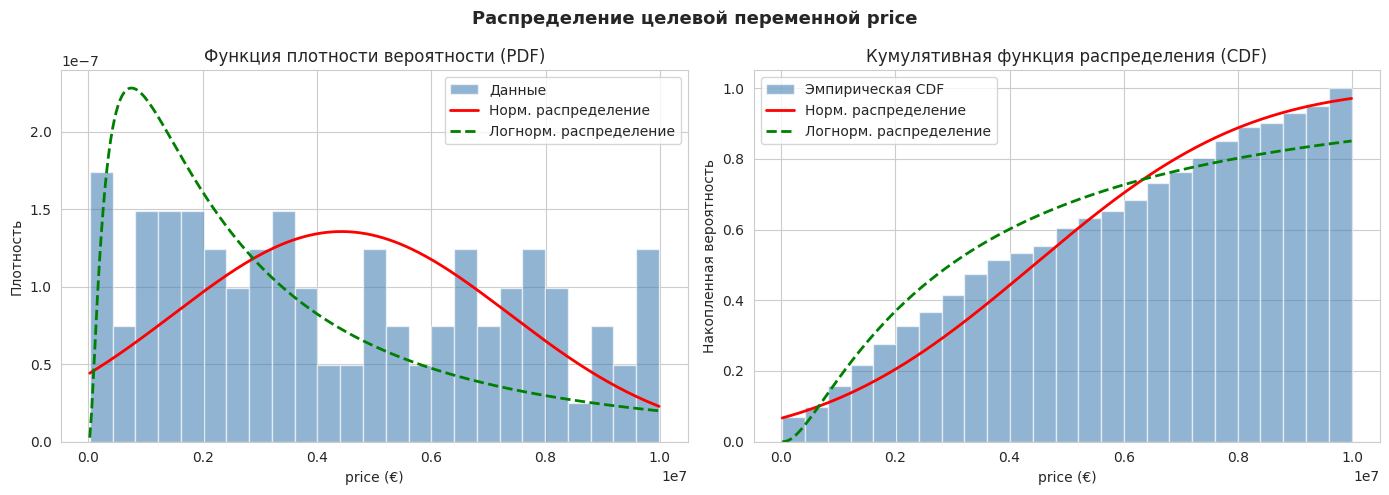

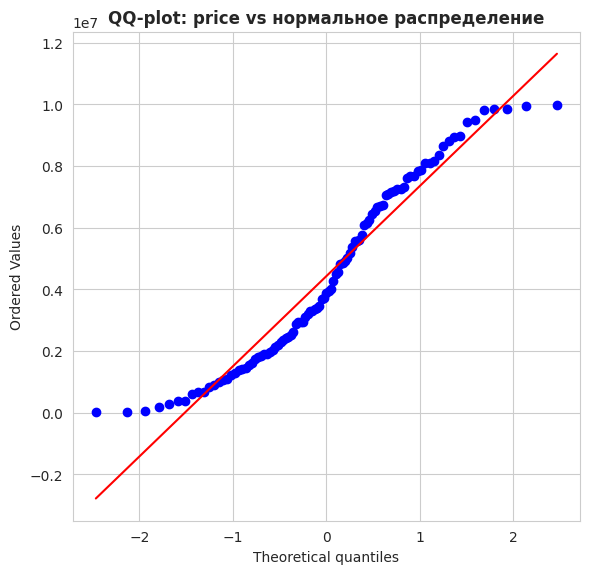

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Распределение целевой переменной price',
             fontsize=13, fontweight='bold')

x = np.linspace(data.min(), data.max(), 300)

# PDF
axes[0].hist(data, bins=25, density=True,
             color='steelblue', edgecolor='white', alpha=0.6, label='Данные')
# Нормальное распределение
mu, sigma = st.norm.fit(data)
axes[0].plot(x, st.norm.pdf(x, mu, sigma),
             'r-', linewidth=2, label='Норм. распределение')
# Логнормальное
params_ln = st.lognorm.fit(data, floc=0)
axes[0].plot(x, st.lognorm.pdf(x, *params_ln),
             'g--', linewidth=2, label='Логнорм. распределение')
axes[0].set_title('Функция плотности вероятности (PDF)')
axes[0].set_xlabel('price (€)')
axes[0].set_ylabel('Плотность')
axes[0].legend()

# CDF
axes[1].hist(data, bins=25, density=True, cumulative=True,
             color='steelblue', edgecolor='white', alpha=0.6, label='Эмпирическая CDF')
axes[1].plot(x, st.norm.cdf(x, mu, sigma),
             'r-', linewidth=2, label='Норм. распределение')
axes[1].plot(x, st.lognorm.cdf(x, *params_ln),
             'g--', linewidth=2, label='Логнорм. распределение')
axes[1].set_title('Кумулятивная функция распределения (CDF)')
axes[1].set_xlabel('price (€)')
axes[1].set_ylabel('Накопленная вероятность')
axes[1].legend()

plt.tight_layout()
plt.show()

# QQ-plot (нормальность)
fig, ax = plt.subplots(figsize=(6, 6))
st.probplot(data, dist="norm", plot=ax)
ax.set_title('QQ-plot: price vs нормальное распределение',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# МОДЕЛИРОВАНИЕ И ПРОГНОЗИРОВАНИЕ (Прогнозирование временных рядов с помощью ARMA/ARIMA-моделей)

## Определение порядка модели (p, d, q)

=== Временной ряд: средняя цена по году постройки ===


,year,avg_price
0,1990,5.128645e+06
1,1991,5.913704e+06
2,1992,6.894438e+06
3,1993,3.409496e+06
4,1994,3.193082e+06
5,1995,1.670233e+06
6,1996,4.641307e+06
7,1997,4.228906e+06
8,1998,3.245033e+06
9,1999,3.149413e+06



Диапазон: 1990 – 2021
Количество точек: 31


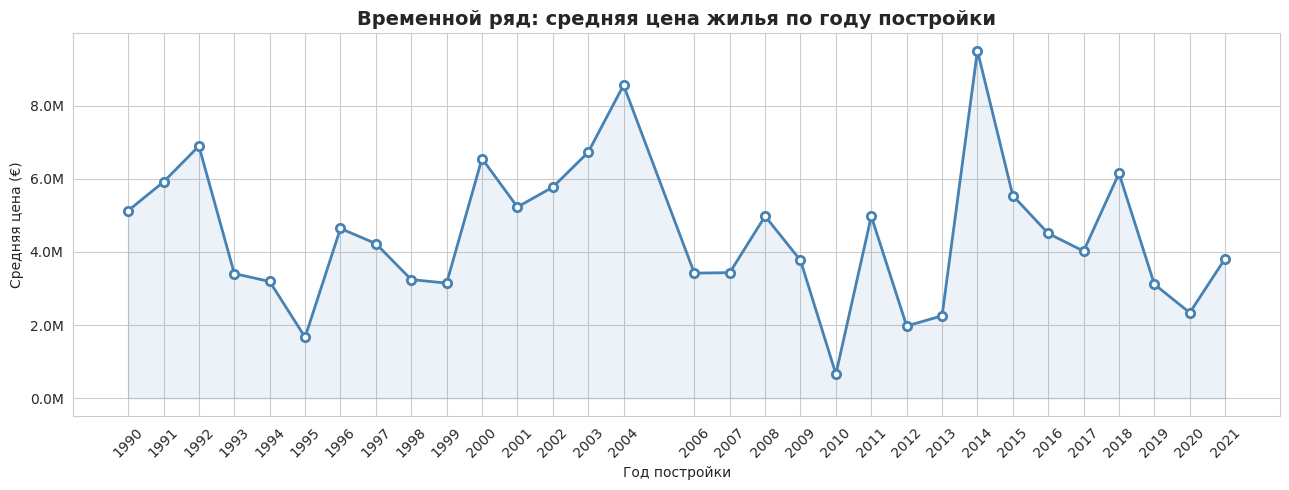

In [ ]:
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')
ts = (df.groupby('made')['price']
        .mean()
        .reset_index()
        .rename(columns={'made': 'year', 'price': 'avg_price'})
        .sort_values('year')
        .reset_index(drop=True))
ts['year'] = ts['year'].astype(int)

print("=== Временной ряд: средняя цена по году постройки ===")
display(ts)
print(f"\nДиапазон: {ts['year'].min()} – {ts['year'].max()}")
print(f"Количество точек: {len(ts)}")

# Визуализация ряда
plt.figure(figsize=(13, 5))
plt.plot(ts['year'], ts['avg_price'], marker='o', linewidth=2,
         color='steelblue', markersize=6,
         markerfacecolor='white', markeredgewidth=2)
plt.fill_between(ts['year'], ts['avg_price'], alpha=0.1, color='steelblue')
plt.title('Временной ряд: средняя цена жилья по году постройки',
          fontsize=14, fontweight='bold')
plt.xlabel('Год постройки')
plt.ylabel('Средняя цена (€)')
plt.xticks(ts['year'], rotation=45)
plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

### Проверка стационарности (тест Дики–Фуллера)

In [ ]:
def adf_test(series, name='ряд'):
    result = adfuller(series, autolag='AIC')
    print(f"Тест Дики–Фуллера: {name}")
    print(f"  ADF-статистика : {result[0]:.4f}")
    print(f"  p-value        : {result[1]:.4f}")
    print(f"  Критические значения:")
    for key, val in result[4].items():
        print(f"    {key}: {val:.4f}")
    if result[1] < 0.05:
        print(f"  → Ряд СТАЦИОНАРЕН (H0 отвергается, p < 0.05)\n")
    else:
        print(f"  → Ряд НЕСТАЦИОНАРЕН (H0 не отвергается, p ≥ 0.05)\n")
    return result[1] < 0.05

is_stationary = adf_test(ts['avg_price'], 'исходный ряд')

#если нестационарный то берем первые разности
if not is_stationary:
    ts['diff1'] = ts['avg_price'].diff().dropna()
    adf_test(ts['diff1'].dropna(), 'ряд после 1-й разности')
    d_order = 1
    print("→ Используем d = 1 (первые разности)")
else:
    d_order = 0
    print("→ Используем d = 0 (разности не нужны)")

Тест Дики–Фуллера: исходный ряд
  ADF-статистика : -3.1971
  p-value        : 0.0202
  Критические значения:
    1%: -3.7112
    5%: -2.9812
    10%: -2.6301
  → Ряд СТАЦИОНАРЕН (H0 отвергается, p < 0.05)

→ Используем d = 0 (разности не нужны)


### ACF и PACF для определения p и q

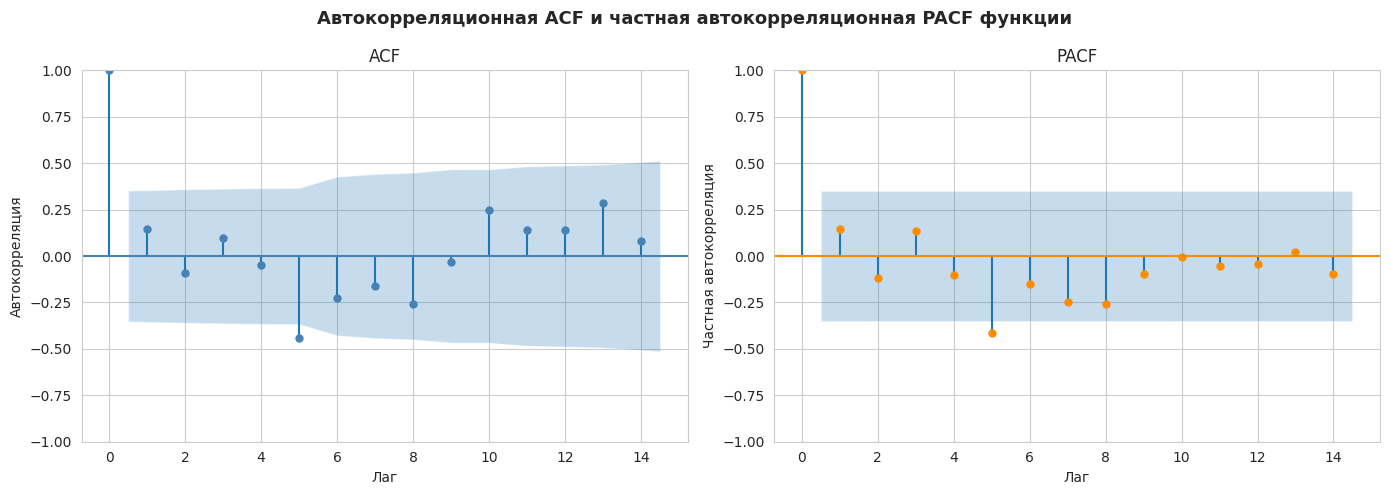

Подсказка для выбора порядка:
  p (AR) - смотреть PACF: количество значимых лагов до обрезания
  q (MA) - смотреть ACF:  количество значимых лагов до обрезания
  d = 0 (из теста Дики–Фуллера)


In [ ]:
series_for_acf = ts['avg_price'] if d_order == 0 else ts['avg_price'].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Автокорреляционная ACF и частная автокорреляционная PACF функции',
             fontsize=13, fontweight='bold')

plot_acf(series_for_acf, lags=min(15, len(series_for_acf)//2 - 1),
         ax=axes[0], color='steelblue', title='ACF')
plot_pacf(series_for_acf, lags=min(15, len(series_for_acf)//2 - 1),
          ax=axes[1], color='darkorange', title='PACF', method='ywm')

axes[0].set_xlabel('Лаг')
axes[0].set_ylabel('Автокорреляция')
axes[1].set_xlabel('Лаг')
axes[1].set_ylabel('Частная автокорреляция')

plt.tight_layout()
plt.show()

print("Подсказка для выбора порядка:")
print("  p (AR) - смотреть PACF: количество значимых лагов до обрезания")
print("  q (MA) - смотреть ACF:  количество значимых лагов до обрезания")
print(f"  d = {d_order} (из теста Дики–Фуллера)")

## Оценивание параметров модели ARIMA

### Подбор наилучшего ARIMA через перебор

In [ ]:
best_aic = np.inf
best_order = None
best_model = None

results_list = []

for p in range(0, 4):
    for q in range(0, 4):
        try:
            model = ARIMA(ts['avg_price'], order=(p, d_order, q))
            fitted = model.fit()
            results_list.append({
                'p': p, 'd': d_order, 'q': q,
                'AIC': round(fitted.aic, 2),
                'BIC': round(fitted.bic, 2)
            })
            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_order = (p, d_order, q)
                best_model = fitted
        except:
            continue

results_df = pd.DataFrame(results_list).sort_values('AIC').head(10)
print("Топ-10 моделей ARIMA по критерию AIC")
display(results_df.reset_index(drop=True))
print(f"\nНаилучшая модель: ARIMA{best_order}  (AIC = {best_aic:.2f})")

Топ-10 моделей ARIMA по критерию AIC


,p,d,q,AIC,BIC
0,0,0,1,990.59,994.89
1,1,0,0,990.76,995.06
2,1,0,2,991.69,998.86
3,2,0,2,991.98,1000.59
4,1,0,1,992.27,998.00
5,2,0,0,992.37,998.11
6,0,0,2,992.44,998.17
7,3,0,0,993.82,1000.99
8,0,0,3,993.89,1001.06
9,2,0,1,994.12,1001.29



Наилучшая модель: ARIMA(0, 0, 1)  (AIC = 990.59)


### Параметры наилучшей модели

In [ ]:
print(f"Сводка модели ARIMA{best_order}")
print(best_model.summary())

Сводка модели ARIMA(0, 0, 1)
                               SARIMAX Results                                
Dep. Variable:              avg_price   No. Observations:                   31
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -492.294
Date:                Wed, 10 Jun 2026   AIC                            990.588
Time:                        09:42:07   BIC                            994.890
Sample:                             0   HQIC                           991.991
                                 - 31                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.477e+06   4.29e+05     10.433      0.000    3.64e+06    5.32e+06
ma.L1          0.1867      0.236      0.789      0.430      -0.277       0.650
sigma2      3.826e+12  

## Прогнозирование на 3 периода вперед

### Прогноз + график

Прогноз на 3 года вперед


,Год,Прогноз в €,Нижняя граница,Верхняя граница
0,2022,4417668.0,583870.0,8251466.0
1,2023,4476715.0,576693.0,8376738.0
2,2024,4476715.0,576693.0,8376738.0


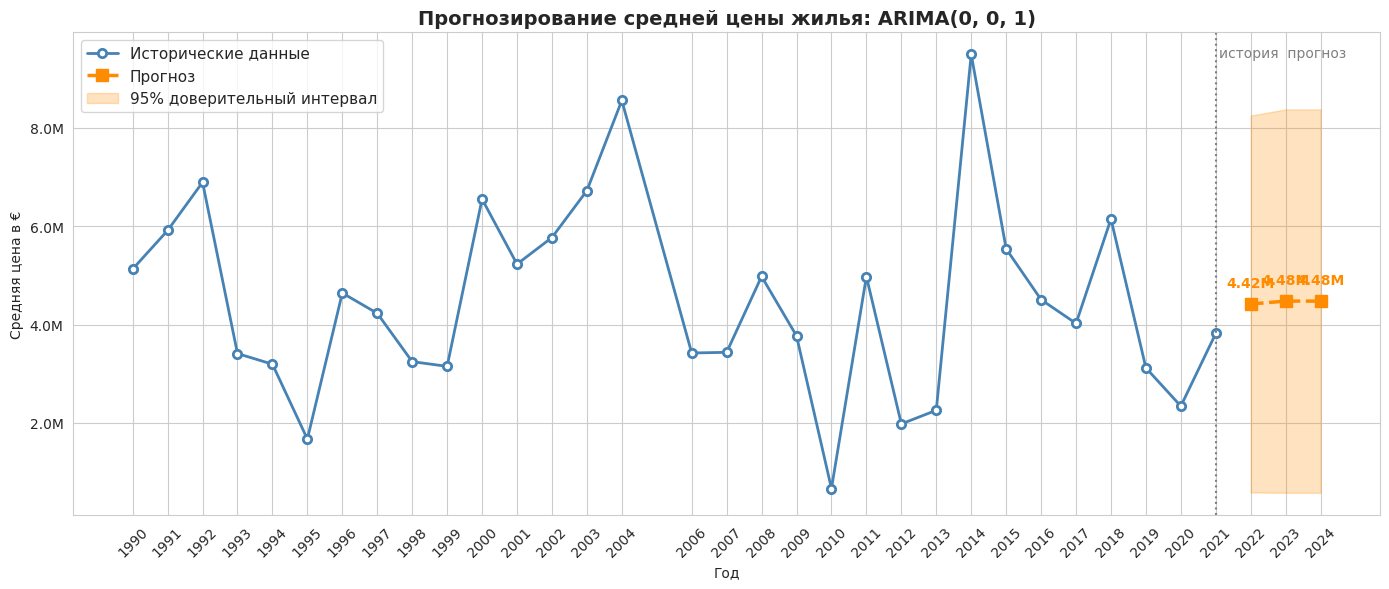

In [ ]:
n_forecast = 3
forecast_result = best_model.get_forecast(steps=n_forecast)
forecast_mean   = forecast_result.predicted_mean
forecast_ci     = forecast_result.conf_int(alpha=0.05)

#годы прогноза
last_year = ts['year'].max()
forecast_years = list(range(last_year + 1, last_year + 1 + n_forecast))

forecast_df = pd.DataFrame({
    'Год':              forecast_years,
    'Прогноз в €':      forecast_mean.values.round(0),
    'Нижняя граница':   forecast_ci.iloc[:, 0].values.round(0),
    'Верхняя граница':  forecast_ci.iloc[:, 1].values.round(0)
})

print("Прогноз на 3 года вперед")
display(forecast_df)

#визуализация прогноза
fig, ax = plt.subplots(figsize=(14, 6))

#исторические данные
ax.plot(ts['year'], ts['avg_price'],
        marker='o', linewidth=2, color='steelblue',
        markersize=6, markerfacecolor='white', markeredgewidth=2,
        label='Исторические данные')

#прогноз
ax.plot(forecast_years, forecast_mean.values,
        marker='s', linewidth=2.5, color='darkorange',
        markersize=8, markerfacecolor='darkorange',
        linestyle='--', label='Прогноз')

#доверительный интервал
ax.fill_between(forecast_years,
                forecast_ci.iloc[:, 0].values,
                forecast_ci.iloc[:, 1].values,
                alpha=0.25, color='darkorange',
                label='95% доверительный интервал')

#вертикальная линия это граница прогноза
ax.axvline(x=last_year, color='grey', linestyle=':', linewidth=1.5)
ax.text(last_year + 0.1, ax.get_ylim()[1] * 0.95,
        'история  прогноз', fontsize=10, color='grey')

#подписи прогнозных значений
for yr, val in zip(forecast_years, forecast_mean.values):
    ax.annotate(f'{val/1e6:.2f}M',
                xy=(yr, val), xytext=(0, 12),
                textcoords='offset points', ha='center',
                fontsize=10, color='darkorange', fontweight='bold')

ax.set_title(f'Прогнозирование средней цены жилья: ARIMA{best_order}',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Год')
ax.set_ylabel('Средняя цена в €')
ax.yaxis.set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(fontsize=11)
ax.set_xticks(list(ts['year']) + forecast_years)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Диагностика остатков

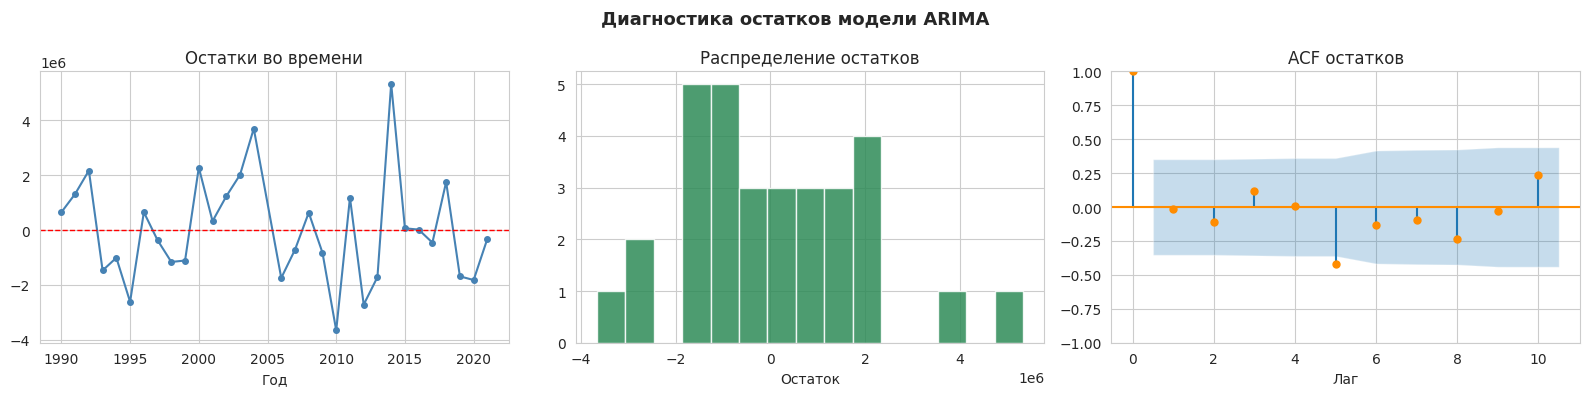

Тест Льюнга–Бокса (автокорреляция остатков)
H0: автокорреляция остатков отсутствует


,lb_stat,lb_pvalue
5,7.762583,0.169815
10,14.045276,0.170936


In [ ]:
residuals = best_model.resid

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Диагностика остатков модели ARIMA',
             fontsize=13, fontweight='bold')

#остатки во времени
axes[0].plot(ts['year'], residuals, color='steelblue',
             marker='o', linewidth=1.5, markersize=4)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Остатки во времени')
axes[0].set_xlabel('Год')

#гистограмма остатков
axes[1].hist(residuals, bins=15, color='seagreen',
             edgecolor='white', alpha=0.85)
axes[1].set_title('Распределение остатков')
axes[1].set_xlabel('Остаток')

#ACF остатков
plot_acf(residuals, lags=min(10, len(residuals)//2 - 1),
         ax=axes[2], color='darkorange', title='ACF остатков')
axes[2].set_xlabel('Лаг')

plt.tight_layout()
plt.show()

#Тест Льюнга–Бокса на автокорреляцию остатков
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuals, lags=[5, 10], return_df=True)
print("Тест Льюнга–Бокса (автокорреляция остатков)")
print("H0: автокорреляция остатков отсутствует")
display(lb_test)